Este código realiza la carga de un modelo entrenado, sus artefactos de preprocesamiento y el conjunto de datos para reconstruir 
exactamente los conjuntos de entrenamiento y prueba originales con el fin de interpretar el modelo.

### **Importación de Librerías y Configuración**
* Carga herramientas para la interpretación de modelos (`shap`).
* Carga utilidades para la lectura de objetos serializados (`joblib`).
* Carga librerías para la manipulación de datos y visualización (`pandas`, `numpy`, `matplotlib`).
* Define una semilla aleatoria estática (`RANDOM_STATE = 42`) para garantizar la reproducibilidad de los resultados.

### **Carga de Artefactos de Machine Learning**
* Importa el pipeline del modelo final entrenado (`pipeline_v3`).
* Recupera el codificador de etiquetas (`le`) utilizado para transformar la variable objetivo.
* Carga la lista con los nombres de las características o columnas finales seleccionadas para el modelo.

### **Lectura y Estructuración de Datos**
* Lee el conjunto de datos procesado desde un archivo CSV (`03_feature_engineering.csv`).
* Separa las características independientes (`X`) eliminando las columnas no deseadas (`id_registro`) y la variable objetivo (`target`).
* Transforma la variable categórica objetivo a un formato numérico empleando el codificador recuperado.
* Filtra el conjunto `X` para mantener únicamente las 55 columnas finales requeridas por el modelo.

### **Reconstrucción del Conjunto de Validación**
* Aplica la función `train_test_split` replicando exactamente los mismos parámetros del entrenamiento original (`test_size=0.2` y la estratificación correspondiente).
* Esto aísla el conjunto de prueba (`X_test_v3`) idéntico al usado en la fase de evaluación.

### **Preparación del Entorno de Reportes**
* Crea de manera automática la estructura de directorios necesaria (`../reports/model_interpretation`) para almacenar las salidas visuales o métricas generadas por el análisis de interpretabilidad sin arrojar errores si la carpeta ya existe.

### **Salida de la Ejecución**
* Confirma que el modelo cuenta con 55 columnas de entrada.
* Identifica las tres clases del problema de clasificación: 'Eficiente', 'Ineficiente' y 'Moderado'.
* Valida que el conjunto de prueba reconstruido consta de 18,908 registros y las 55 variables correspondientes.


In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

pipeline_v3 = joblib.load(r"..\models\modelo_perfil_energetico_final_v3.joblib")
le = joblib.load(r"..\models\label_encoder_v3.joblib")
columnas_finales_v3 = joblib.load(r"..\models\columnas_requeridas_final_v3.joblib")

print(f"Columnas del modelo: {len(columnas_finales_v3)}")
print(f"Clases: {list(le.classes_)}")

ruta_dataset = r"..\datasets\processed\03_feature_engineering.csv"
target = "perfil_energetico"

df = pd.read_csv(ruta_dataset, sep=",", encoding="utf-8-sig")

X = df.drop(columns=["id_registro", target])
y_encoded = le.transform(df[target])

X_v3 = X[columnas_finales_v3]

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE
)

print("Test set reconstruido:", X_test_v3.shape)

os.makedirs(r"..\reports\model_interpretation", exist_ok=True)

Columnas del modelo: 55
Clases: ['Eficiente', 'Ineficiente', 'Moderado']
Test set reconstruido: (18908, 55)


Este código extrae los componentes del pipeline para transformar las variables de prueba, inicializa el explicador de SHAP basado en árboles y calcula las contribuciones de las características para una muestra, validando el formato de salida multi-clase.

### **Extracción de Componentes y Transformación de Datos**
* Descompone el pipeline (`pipeline_v3`) para aislar de forma independiente el estimador final (`classifier`) y el flujo de preprocesamiento (`preprocessor`).
* Ejecuta la transformación secuencial de los datos crudos de prueba (`X_test_v3`) para aplicar los escalamientos o codificaciones previas al modelo.
* Convierte el arreglo numérico resultante de vuelta a un DataFrame de Pandas, restituyendo los nombres de las columnas finales y manteniendo los índices originales de los registros.

### **Inicialización del Explicador SHAP**
* Instancia un objeto `TreeExplainer` utilizando el clasificador extraído. Se emplea este optimizador específico debido a que el algoritmo base corresponde a un modelo fundamentado en árboles de decisión.

### **Cálculo de Impactos en una Muestra**
* Toma una muestra pequeña conformada por los primeros 50 registros (`iloc[:50]`) de los datos transformados para agilizar la validación del comportamiento de la librería.
* Genera la matriz de valores SHAP correspondientes a la muestra para medir el impacto positivo o negativo de cada variable en las predicciones.

### **Validación de Estructura Multi-clase**
* Evalúa mediante condicionales si el objeto devuelto es una lista de arreglos o un arreglo multidimensional homogéneo. Esto previene fallos de indexación derivados de los cambios de compatibilidad entre diferentes versiones de la librería SHAP.

### **Salida de la Ejecución**
* Confirma la creación exitosa del explicador.
* Identifica que la salida es un **array único con dimensiones (50, 55, 3)**, lo que representa 50 registros evaluados, 55 variables explicativas y 3 clases de salida posibles.
* Muestra el orden de clasificación del modelo (`'Eficiente'`, `'Ineficiente'`, `'Moderado'`), indispensable para interpretar correctamente a qué clase corresponde cada capa de la dimensión tridimensional de SHAP.


In [2]:
clasificador = pipeline_v3.named_steps["classifier"]
preprocessor_v3 = pipeline_v3.named_steps["preprocessor"]

X_test_v3_transformed = preprocessor_v3.transform(X_test_v3)
X_test_v3_df = pd.DataFrame(X_test_v3_transformed, columns=columnas_finales_v3, index=X_test_v3.index)

explainer = shap.TreeExplainer(clasificador)
print("Explainer creado.")

muestra_prueba = X_test_v3_df.iloc[:50]
shap_values_prueba = explainer.shap_values(muestra_prueba)

if isinstance(shap_values_prueba, list):
    print(f"Formato devuelto: lista de {len(shap_values_prueba)} arrays (uno por clase)")
    print(f"Shape por clase: {shap_values_prueba[0].shape}")
else:
    print(f"Formato devuelto: array único, shape: {shap_values_prueba.shape}")

print(f"Orden de clases del modelo: {list(le.classes_)}")

Explainer creado.
Formato devuelto: array único, shape: (50, 55, 3)
Orden de clases del modelo: ['Eficiente', 'Ineficiente', 'Moderado']


Este código realiza el muestreo de los datos transformados para calcular los valores SHAP globales, genera un gráfico de barras de importancia de variables por clase, calcula la importancia media general de las características y exporta los resultados numéricos y visuales a los directorios de reportes.

### **Muestreo Controlado de Datos**
* Importa la función de división para extraer un subconjunto aleatorio manejable.
* Evalúa si el volumen de datos de prueba supera los 5,000 registros para evitar sobrecostos computacionales en el cálculo de SHAP.
* Extrae una muestra estratificada exacta de 5,000 registros conservando la distribución original de la variable objetivo en caso de superar el umbral.
* Mantiene el conjunto completo original si la cantidad de registros es menor a la condición establecida.

### **Cálculo de SHAP Global y Reestructuración**
* Ejecuta el cálculo de las contribuciones de las variables sobre la muestra de datos seleccionada mediante el explicador configurado previamente.
* Descompone la matriz tridimensional homogénea resultante en una lista de arreglos independientes, donde cada elemento indexado corresponde a las atribuciones de una clase específica del modelo.

### **Visualización de Importancia Global**
* Inicializa un lienzo de dimensiones extendidas con Matplotlib para la correcta disposición de las etiquetas de texto.
* Invoca la función gráfica resumen de SHAP configurada en modo barras para representar el impacto acumulado y comparativo de cada variable entre las distintas clases.
* Configura los nombres explícitos de las clases recuperados del codificador de etiquetas.
* Ajusta los márgenes dinámicos del lienzo, exporta la gráfica terminada en formato PNG de alta resolución a la carpeta de reportes y despliega el resultado en el entorno de desarrollo.

### **Cálculo de Métrica Global y Exportación de Datos**
* Calcula el valor absoluto de todos los impactos SHAP y extrae la media aritmética colapsando los ejes de las instancias y de las clases para consolidar un valor único de importancia por variable.
* Estructura un DataFrame de Pandas acoplando los nombres de las columnas finales con sus respectivas métricas de importancia media calculadas.
* Ordena los registros de manera descendente para priorizar los factores con mayor influencia en el modelo y genera un índice secuencial que sirve como ranking de posición.
* Imprime en consola un resumen formateado de las veinte variables principales sin incluir los índices de fila por defecto.
* Almacena el listado y el ranking estructurado en un archivo CSV dentro de la ruta dedicada a la interpretación del modelo.


Muestra para SHAP global: (5000, 55)
Shape de shap_values_global: (5000, 55, 3)


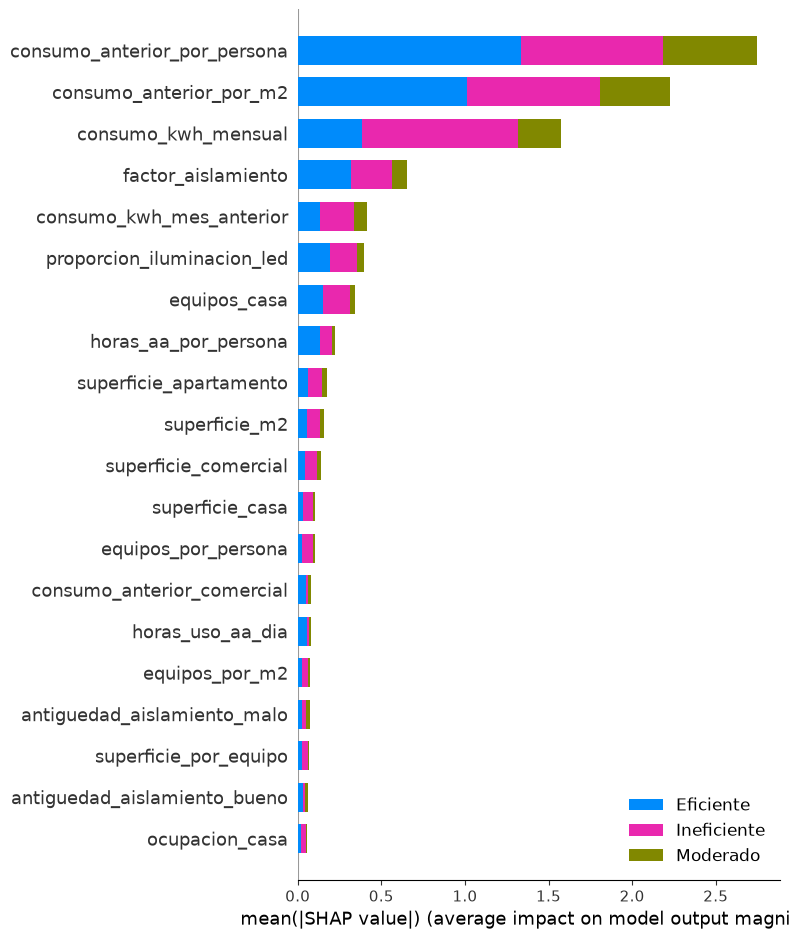

                     feature  importancia_shap  ranking
consumo_anterior_por_persona          0.915622        1
     consumo_anterior_por_m2          0.742371        2
         consumo_kwh_mensual          0.525129        3
          factor_aislamiento          0.217348        4
    consumo_kwh_mes_anterior          0.138510        5
  proporcion_iluminacion_led          0.132318        6
                equipos_casa          0.113711        7
        horas_aa_por_persona          0.075171        8
      superficie_apartamento          0.059206        9
               superficie_m2          0.052494       10
        superficie_comercial          0.046445       11
             superficie_casa          0.035285       12
         equipos_por_persona          0.034083       13
  consumo_anterior_comercial          0.027365       14
            horas_uso_aa_dia          0.025927       15
              equipos_por_m2          0.024367       16
 antiguedad_aislamiento_malo          0.023588  

In [24]:
from sklearn.model_selection import train_test_split as tts_sample

if len(X_test_v3_df) > 5000:
    X_shap_sample, _, y_shap_sample, _ = tts_sample(
        X_test_v3_df, y_test_v3, train_size=5000, stratify=y_test_v3, random_state=RANDOM_STATE
    )
else:
    X_shap_sample, y_shap_sample = X_test_v3_df, y_test_v3

print(f"Muestra para SHAP global: {X_shap_sample.shape}")

shap_values_global = explainer.shap_values(X_shap_sample)
print(f"Shape de shap_values_global: {shap_values_global.shape}")

shap_values_por_clase = [shap_values_global[:, :, i] for i in range(len(le.classes_))]

plt.figure(figsize=(22, 10))
shap.summary_plot(
    shap_values_por_clase, X_shap_sample,
    class_names=list(le.classes_),
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(r"..\reports\model_interpretation\shap_summary_global.png", dpi=150, bbox_inches="tight")
plt.show()

importancia_media = np.abs(shap_values_global).mean(axis=(0, 2))

ranking_shap = pd.DataFrame({
    "feature": columnas_finales_v3,
    "importancia_shap": importancia_media
}).sort_values("importancia_shap", ascending=False).reset_index(drop=True)

ranking_shap["ranking"] = ranking_shap.index + 1
print(ranking_shap.head(20).to_string(index=False))

ranking_shap.to_csv(r"..\reports\model_interpretation\ranking_importancia_shap.csv", index=False, encoding="utf-8-sig")

Este código calcula las predicciones del modelo y sus respectivas probabilidades en el conjunto de prueba, construye un DataFrame consolidado de análisis con etiquetas legibles y extrae de forma automatizada el caso con mayor nivel de confianza predictiva para cada clase con fines de estudio.

### **Generación de Predicciones y Consolidación de Datos**
* Calcula los arreglos de probabilidad estimados para cada una de las clases del modelo sobre los datos de prueba transformados.
* Genera las predicciones categóricas directas asignando la clase final para cada registro analizado.
* Crea una copia independiente del conjunto de características de prueba para estructurar un nuevo espacio de análisis de datos.
* Reinvierte la codificación numérica de la variable objetivo real y de las predicciones para transformarlas de nuevo a sus nombres de texto originales.
* Incorpora columnas individuales para mapear la probabilidad asignada a cada categoría y extrae de forma matricial la probabilidad máxima registrada por fila como métrica del nivel de confianza del clasificador.

### **Extracción Automatizada de Casos de Estudio**
* Inicializa un diccionario vacío estructurado para compilar las instancias seleccionadas de cada categoría de respuesta.
* Itera a través de las distintas etiquetas de clases válidas configuradas en el codificador del proyecto.
* Filtra el conjunto consolidado aislando de manera estricta los registros que representan aciertos verdaderos, donde la clase real coincide plenamente con la clase predicha por el modelo.
* Ordena el subconjunto de aciertos de forma descendente en función de su valor de confianza matemática.
* Extrae la primera instancia de la lista para registrar el caso de éxito más contundente y representativo de cada clase dentro del diccionario de estudio.

### **Impresión y Visualización de Métricas de Confianza**
* Recorre la estructura de casos recopilados para desplegar la información de diagnóstico en la consola del sistema.
* Muestra el nombre de la clase evaluada junto con el identificador o índice de fila original recuperado del conjunto de prueba.
* Imprime con formato de precisión de cuatro decimales el valor de confianza global de la predicción y el desglose completo de probabilidades para comprobar la distribución asignada entre las tres categorías posibles.


In [32]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

probas = pipeline_v3.predict_proba(X_test_v3)
predicciones = pipeline_v3.predict(X_test_v3)

df_test_analisis = X_test_v3.copy()
df_test_analisis["clase_real"] = le.inverse_transform(y_test_v3)
df_test_analisis["clase_predicha"] = le.inverse_transform(predicciones)
df_test_analisis["prob_Eficiente"] = probas[:, 0]
df_test_analisis["prob_Ineficiente"] = probas[:, 1]
df_test_analisis["prob_Moderado"] = probas[:, 2]
df_test_analisis["confianza"] = probas.max(axis=1)

casos_estudio = {}
for clase in le.classes_:
    subset = df_test_analisis[
        (df_test_analisis["clase_real"] == clase) &
        (df_test_analisis["clase_predicha"] == clase)
    ]
    caso = subset.sort_values("confianza", ascending=False).iloc[0]
    casos_estudio[clase] = caso

for clase, caso in casos_estudio.items():
    print(f"\n=== Clase: {clase} (índice test: {caso.name}) ===")
    print(f"Confianza del modelo: {caso['confianza']:.4f}")
    print(f"Probabilidades -> Eficiente: {caso['prob_Eficiente']:.4f} | "
          f"Ineficiente: {caso['prob_Ineficiente']:.4f} | Moderado: {caso['prob_Moderado']:.4f}")



=== Clase: Eficiente (índice test: 73863) ===
Confianza del modelo: 0.9969
Probabilidades -> Eficiente: 0.9969 | Ineficiente: 0.0002 | Moderado: 0.0029

=== Clase: Ineficiente (índice test: 45695) ===
Confianza del modelo: 0.9982
Probabilidades -> Eficiente: 0.0001 | Ineficiente: 0.9982 | Moderado: 0.0017

=== Clase: Moderado (índice test: 90191) ===
Confianza del modelo: 0.9807
Probabilidades -> Eficiente: 0.0111 | Ineficiente: 0.0081 | Moderado: 0.9807


Este código itera sobre los casos de estudio previamente seleccionados para calcular las contribuciones locales de SHAP, genera gráficos de cascada visuales para cada clase y extrae de forma estructurada las cinco variables con mayor impacto predictivo junto con sus valores reales y direcciones de influencia.

### **Inicialización e Identificación del Caso**
* Crea un diccionario vacío destinado a almacenar el consolidado final de las justificaciones técnicas y métricas por clase.
* Recorre cada uno de los registros del diccionario de casos de estudio, identificando el índice original del DataFrame y el índice numérico correspondiente a la clase evaluada dentro del codificador de etiquetas.

### **Extracción de Datos y Cálculo SHAP Local**
* Aísla el registro de interés en su versión transformada para el cálculo matemático del modelo y extrae la fila correspondiente con las variables crudas originales para mejorar la legibilidad en los reportes.
* Calcula los valores SHAP individuales para la instancia seleccionada utilizando el explicador configurado.
* Instancia un objeto de explicación nativo de SHAP acoplando los impactos específicos de la clase evaluada, el valor base o esperado del modelo, las magnitudes reales del registro y el listado final de variables.

### **Generación y Exportación de Gráficos de Cascada**
* Inicializa un lienzo gráfico con dimensiones optimizadas mediante Matplotlib.
* Despliega un gráfico de cascada de SHAP parametrizado para mostrar un máximo de doce variables explicativas, inhabilitando el dibujado automático para permitir personalizaciones del diseño.
* Incorpora un título dinámico que detalla el caso de estudio analizado junto con su identificador de fila original.
* Ajusta los márgenes limpios del lienzo, exporta la imagen de alta resolución en formato PNG al directorio dedicado de reportes y visualiza la figura en el cuaderno.

### **Extracción de Características Clave y Estructuración de Datos**
* Consolida un DataFrame de Pandas que vincula el nombre de cada variable, su valor real observado y su peso de contribución SHAP específico.
* Ordena los registros de manera descendente según el valor absoluto del impacto de SHAP para aislar estrictamente las cinco variables de mayor relevancia en la decisión del clasificador.
* Evalúa el signo matemático de la contribución para determinar y etiquetar textualmente si la variable empuja a favor o en contra de la asignación de la clase actual.
* Almacena de manera indexada en el diccionario de justificaciones el resumen del índice, el nivel de confianza, el desglose de probabilidades y la tabla de variables clave de la instancia.
* Imprime en la consola un reporte formateado que muestra el listado ordenado de las variables dominantes sin incluir los índices de fila por defecto.


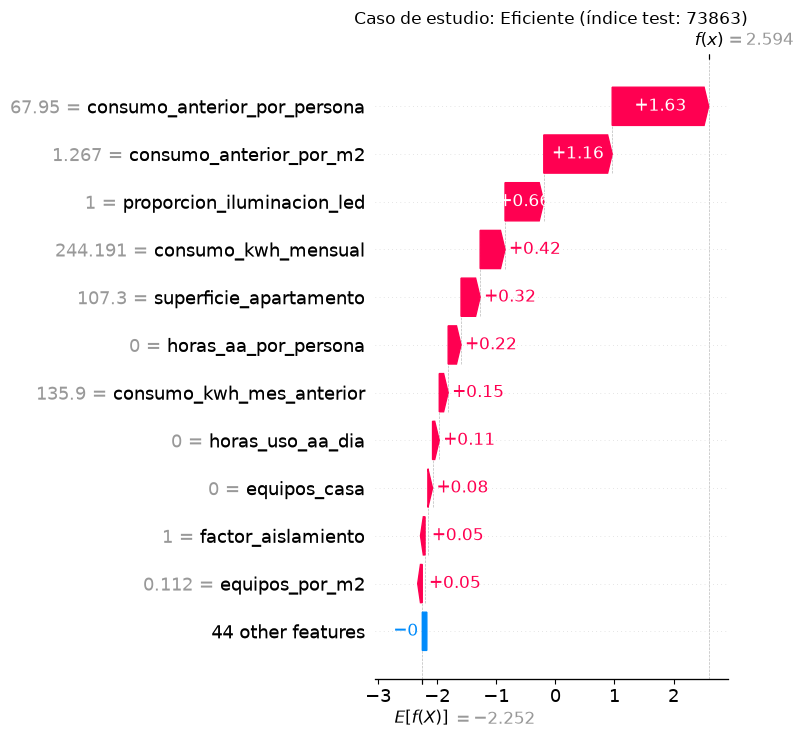


=== Eficiente — Top 5 variables de influencia ===
                     feature  valor_real  shap_value              direccion
consumo_anterior_por_persona   67.950000    1.632650 empuja hacia Eficiente
     consumo_anterior_por_m2    1.266542    1.157806 empuja hacia Eficiente
  proporcion_iluminacion_led    1.000000    0.655784 empuja hacia Eficiente
         consumo_kwh_mensual  244.191281    0.420946 empuja hacia Eficiente
      superficie_apartamento  107.300000    0.323458 empuja hacia Eficiente


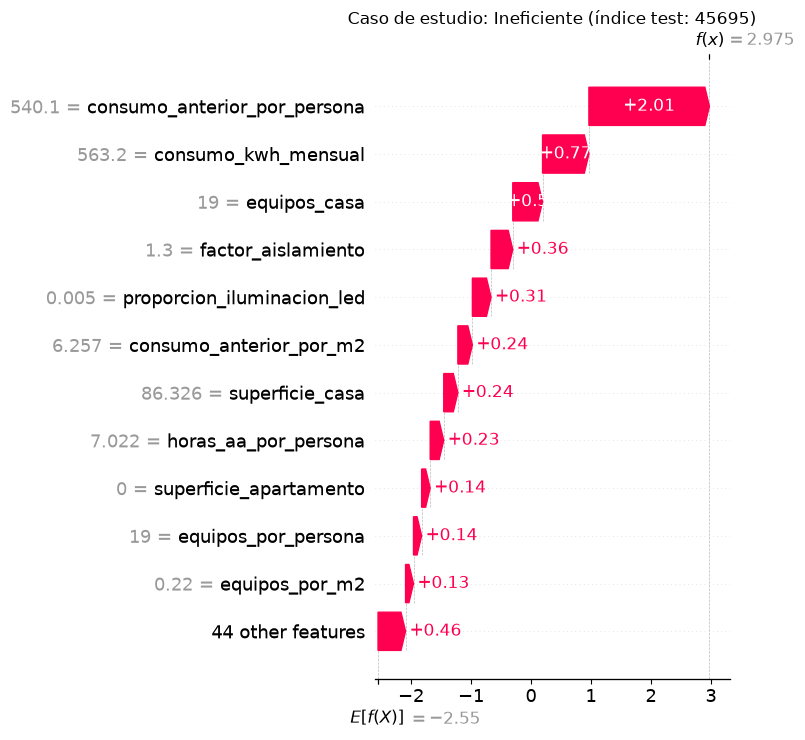


=== Ineficiente — Top 5 variables de influencia ===
                     feature  valor_real  shap_value                direccion
consumo_anterior_por_persona     540.100    2.009199 empuja hacia Ineficiente
         consumo_kwh_mensual     563.200    0.772704 empuja hacia Ineficiente
                equipos_casa      19.000    0.496489 empuja hacia Ineficiente
          factor_aislamiento       1.300    0.362311 empuja hacia Ineficiente
  proporcion_iluminacion_led       0.005    0.310813 empuja hacia Ineficiente


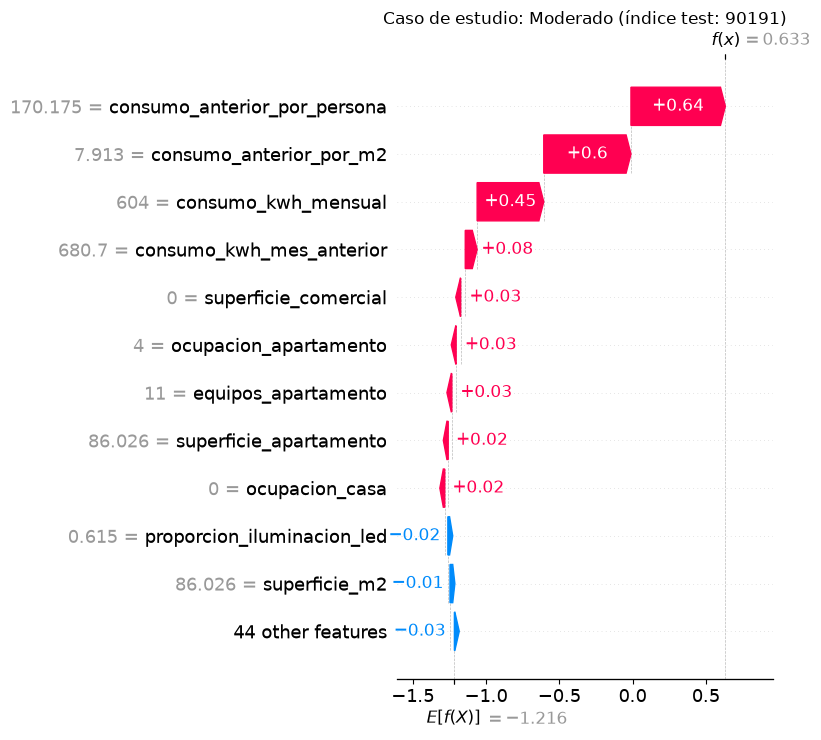


=== Moderado — Top 5 variables de influencia ===
                     feature  valor_real  shap_value             direccion
consumo_anterior_por_persona  170.175000    0.644103 empuja hacia Moderado
     consumo_anterior_por_m2    7.912706    0.595099 empuja hacia Moderado
         consumo_kwh_mensual  604.000000    0.454558 empuja hacia Moderado
    consumo_kwh_mes_anterior  680.700000    0.081072 empuja hacia Moderado
        superficie_comercial    0.000000    0.031615 empuja hacia Moderado


In [16]:
justificaciones_tecnicas = {}

for clase, caso in casos_estudio.items():
    indice = caso.name
    clase_idx = list(le.classes_).index(clase)

   
    fila_transformada = X_test_v3_df.loc[[indice]]
    fila_cruda = X_test_v3.loc[indice, columnas_finales_v3]

    shap_individual = explainer.shap_values(fila_transformada)  

    explicacion = shap.Explanation(
        values=shap_individual[0, :, clase_idx],
        base_values=explainer.expected_value[clase_idx],
        data=fila_cruda.values,
        feature_names=columnas_finales_v3
    )

    # Waterfall plot
    plt.figure(figsize=(10, 8))
    shap.plots.waterfall(explicacion, max_display=12, show=False)
    plt.title(f"Caso de estudio: {clase} (índice test: {indice})")
    plt.tight_layout()
    plt.savefig(rf"..\reports\model_interpretation\shap_waterfall_{clase}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Top 5 variables de mayor influencia (valor absoluto de SHAP)
    contribuciones = pd.DataFrame({
        "feature": columnas_finales_v3,
        "valor_real": fila_cruda.values,
        "shap_value": shap_individual[0, :, clase_idx]
    }).sort_values("shap_value", key=np.abs, ascending=False).head(5)

    contribuciones["direccion"] = contribuciones["shap_value"].apply(
        lambda v, clase=clase: f"empuja hacia {clase}" if v > 0 else f"empuja en contra de {clase}"
    )

    justificaciones_tecnicas[clase] = {
        "indice_test": indice,
        "confianza": caso["confianza"],
        "probabilidades": {c: caso[f"prob_{c}"] for c in le.classes_},
        "top_variables": contribuciones
    }

    print(f"\n=== {clase} — Top 5 variables de influencia ===")
    print(contribuciones.to_string(index=False))

Este código genera gráficos de dispersión de dependencia para validar el comportamiento de las variables clave en toda la muestra analizada, estructura una matriz formal de evaluación de hipótesis para contrastar las predicciones del modelo con las reglas de negocio del sector y exporta los resultados en formatos visuales y tabulares.

### **Generación de Gráficos de Dependencia**
* Define un listado con las cuatro variables de mayor interés para realizar el análisis de sensibilidad y comportamiento global.
* Configura una cuadrícula bidimensional de gráficos mediante Matplotlib con dimensiones proporcionales para asegurar una visualización clara de las tendencias.
* Itera de manera automática sobre las variables seleccionadas extrayendo sus índices posicionales y aislando la capa tridimensional de impactos SHAP correspondiente de forma exclusiva a la clase calificada como ineficiente.
* Construye diagramas de dispersión ajustando la transparencia y el tamaño de los puntos de datos para mitigar problemas de solapamiento visual ante altas densidades de registros.
* Incorpora líneas de referencia horizontales en el punto cero para discriminar con exactitud los rangos donde la variable cambia de aportar positivamente a restar probabilidad en la predicción.
* Etiqueta de manera dinámica los ejes y los títulos de cada panel para su correcta documentación técnica.
* Optimiza los espacios entre subgráficos y exporta el panel consolidado en alta resolución hacia el directorio de almacenamiento de reportes visuales antes de renderizarlo en el entorno de desarrollo.

### **Estructuración y Validación de Reglas de Negocio**
* Instancia un DataFrame de Pandas para documentar y contrastar de manera cualitativa y cuantitativa seis hipótesis clave del dominio del negocio.
* Consolida campos específicos para detallar la hipótesis de negocio evaluada, el nombre técnico de las variables asociadas y las evidencias numéricas extraídas directamente de los rankings globales o de los casos individuales de estudio.
* Clasifica el estatus de validación del modelo utilizando categorías descriptivas para señalar el éxito completo de la regla, el cumplimiento parcial por debilidad de la señal o la inaplicabilidad de la hipótesis debido a la exclusión previa de variables durante la ingeniería de características.

### **Exportación y Reporte de Resultados**
* Despliega en la consola del sistema la tabla consolidada en formato de texto plano sin incluir los índices secuenciales para facilitar su lectura rápida de auditoría.
* Serializa y almacena la matriz de validación en un archivo CSV en la ruta local destinada a la interpretación del modelo, implementando la codificación de caracteres adecuada para asegurar la correcta compatibilidad de los textos y caracteres especiales.


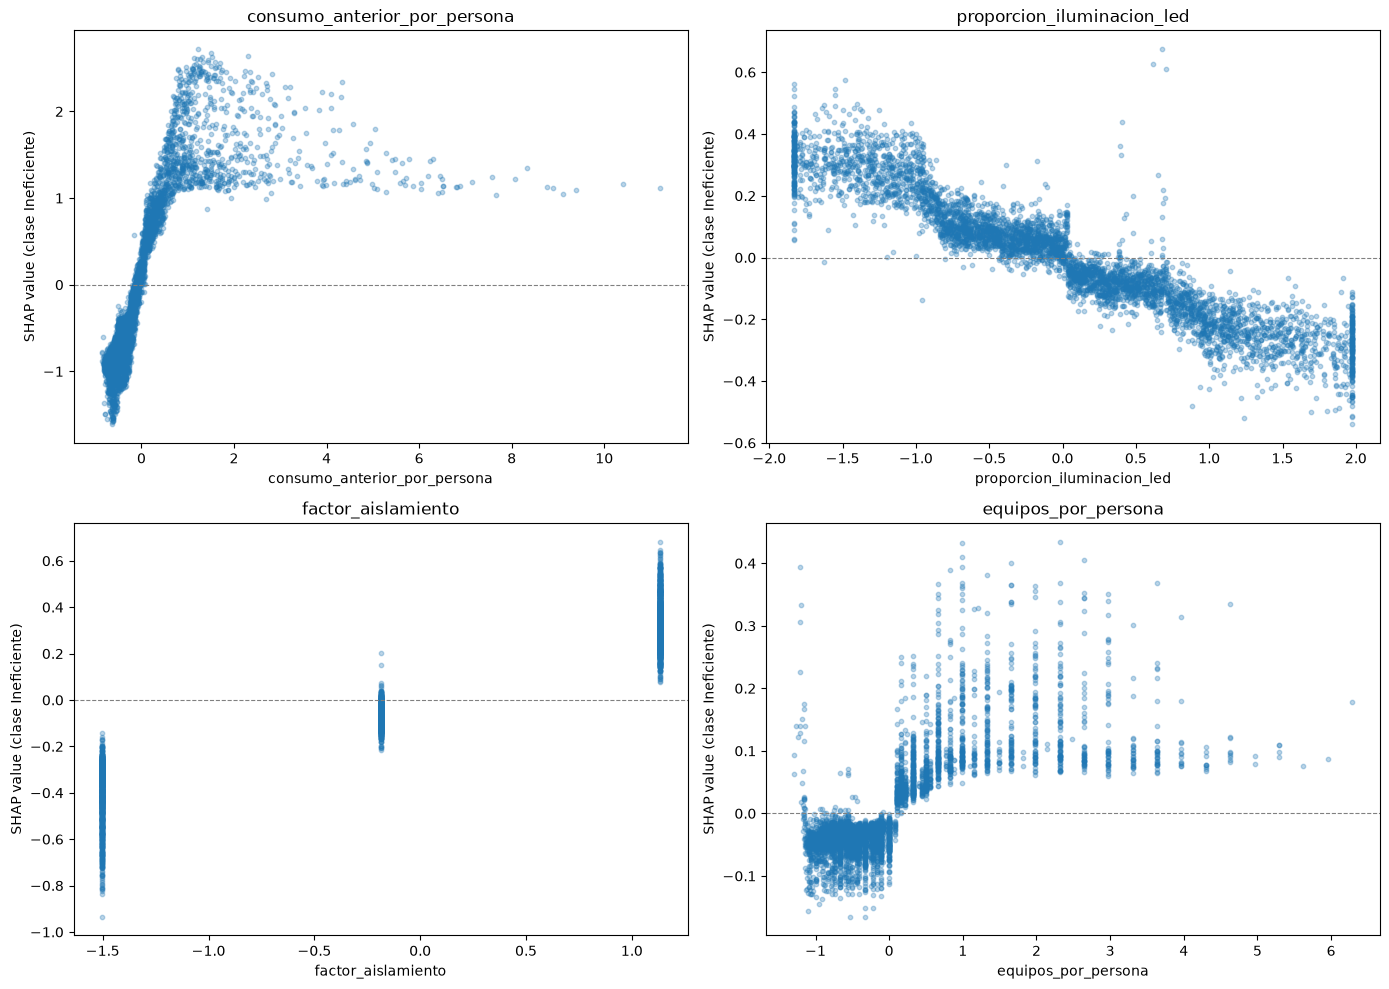

                                                                         regla                          variable_clave                                                                                                                                               evidencia                                                                                                         validada
      A mayor consumo histórico por persona, mayor probabilidad de Ineficiente            consumo_anterior_por_persona                     Ranking SHAP global: #1 en importancia. Casos de estudio monotónicos: 67.95 (Eficiente) < 170.18 (Moderado) < 540.10 (Ineficiente).                                                                                                               Sí
                 A mayor % de iluminación LED, mayor probabilidad de Eficiente              proporcion_iluminacion_led                       Caso Eficiente: 100% LED empuja hacia Eficiente (SHAP +0.656). Caso Ineficiente: 0.5% LED e

In [23]:
# --- Validación con dependence plots (relación variable -> SHAP en TODA la muestra, no solo 3 casos) ---
top_features_validar = ["consumo_anterior_por_persona", "proporcion_iluminacion_led", "factor_aislamiento", "equipos_por_persona"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features_validar):
    feature_idx = columnas_finales_v3.index(feature)
    shap_ineficiente = shap_values_global[:, feature_idx, 1]  # clase Ineficiente
    valores_feature = X_shap_sample[feature].values
    axes[i].scatter(valores_feature, shap_ineficiente, alpha=0.3, s=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("SHAP value (clase Ineficiente)")
    axes[i].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[i].set_title(feature)

plt.tight_layout()
plt.savefig(r"..\reports\model_interpretation\shap_dependence_reglas_negocio.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Tabla formal de validación de reglas de negocio ---
reglas_negocio = pd.DataFrame([
    {
        "regla": "A mayor consumo histórico por persona, mayor probabilidad de Ineficiente",
        "variable_clave": "consumo_anterior_por_persona",
        "evidencia": "Ranking SHAP global: #1 en importancia. Casos de estudio monotónicos: 67.95 (Eficiente) < 170.18 (Moderado) < 540.10 (Ineficiente).",
        "validada": "Sí"
    },
    {
        "regla": "A mayor % de iluminación LED, mayor probabilidad de Eficiente",
        "variable_clave": "proporcion_iluminacion_led",
        "evidencia": "Caso Eficiente: 100% LED empuja hacia Eficiente (SHAP +0.656). Caso Ineficiente: 0.5% LED empuja hacia Ineficiente (SHAP +0.311).",
        "validada": "Sí"
    },
    {
        "regla": "Peor aislamiento térmico incrementa la probabilidad de Ineficiente",
        "variable_clave": "factor_aislamiento",
        "evidencia": "Ranking SHAP global: #4 en importancia. Caso Ineficiente: factor=1.3 empuja hacia Ineficiente.",
        "validada": "Parcial — dirección confirmada, falta contrastar la escala del factor con quien construyó el feature engineering"
    },
    {
        "regla": "Mayor densidad de equipos eléctricos incrementa la probabilidad de Ineficiente",
        "variable_clave": "equipos_por_persona / equipos_casa",
        "evidencia": "Caso Ineficiente: 19 equipos empuja hacia Ineficiente (SHAP +0.496). Presente en ranking global (#7, #13).",
        "validada": "Sí"
    },
    {
        "regla": "Uso intensivo de aire acondicionado incrementa la probabilidad de Ineficiente",
        "variable_clave": "horas_aa_por_persona / horas_uso_aa_dia",
        "evidencia": "Presente en el ranking global (#8, #15) pero con importancia baja — el modelo solo ve horas de uso, no cantidad de unidades ni consumo real del equipo.",
        "validada": "Parcial — señal débil, dominio incompleto"
    },
    {
        "regla": "Escasa generación solar incrementa la probabilidad de Ineficiente",
        "variable_clave": "N/A",
        "evidencia": "El dominio de generación solar fue excluido del modelo v3 por no ser capturable desde el formulario (ver notebook 06_Modelos, Paso 16).",
        "validada": "No aplicable — el modelo no puede evaluar esta regla"
    },
])

print(reglas_negocio.to_string(index=False))
reglas_negocio.to_csv(r"..\reports\model_interpretation\validacion_reglas_negocio.csv", index=False,encoding="utf-8-sig")

Este código realiza una auditoría de ingeniería de características sobre la variable del factor de aislamiento, con la finalidad de resolver la incertidumbre de su validación parcial mediante el contraste directo entre su representación numérica continua y sus categorías textuales originales.

### **Extracción de Mapeos Únicos**
* Filtra el conjunto de datos de prueba original para aislar exclusivamente la columna continua del factor de aislamiento junto con las variables codificadas de forma binaria que representan las categorías de aislamiento bueno, regular y malo.
* Aplica un filtro de eliminación de registros duplicados para consolidar un listado limpio que exponga únicamente las combinaciones únicas y las reglas de transformación existentes en el conjunto de datos.

### **Ordenamiento de Control y Diagnóstico**
* Ordena los registros resultantes de manera ascendente en función de la magnitud numérica del factor de aislamiento para identificar con precisión si los valores más altos corresponden a un desempeño térmico deficiente o eficiente.
* Despliega la matriz de mapeo formateada en la consola del sistema para auditar visualmente la consistencia matemática de la variable y confirmar si la dirección del impacto SHAP se alinea correctamente con la lógica del negocio antes de emitir un dictamen final.


In [25]:
# --- Paso previo: confirmar la dirección real de factor_aislamiento ---
verificacion_aislamiento = X_test_v3[
    ["factor_aislamiento", "aislamiento_termico_Bueno", "aislamiento_termico_Malo", "aislamiento_termico_Regular"]
].drop_duplicates().sort_values("factor_aislamiento")
print(verificacion_aislamiento)

       factor_aislamiento  aislamiento_termico_Bueno  \
58731                 0.7                          1   
54959                 1.0                          0   
60495                 1.3                          0   

       aislamiento_termico_Malo  aislamiento_termico_Regular  
58731                         0                            0  
54959                         0                            1  
60495                         1                            0  


Este código establece umbrales estadísticos de referencia basados estrictamente en los datos de entrenamiento para prevenir sesgos de evaluación, define un catálogo de reglas de negocio parametrizadas para emitir alertas y construye un motor de recomendación inteligente guiado por los valores SHAP que extrae planes de acción personalizados para los casos de ineficiencia energética.

### **Configuración de Umbrales Estadísticos de Control**
* Calcula percentiles específicos utilizando exclusivamente el conjunto de datos de entrenamiento con el objetivo de resguardar la integridad metodológica y evitar el filtrado de información del conjunto de prueba.
* Determina cotas críticas superiores e inferiores para variables clave como el consumo histórico, el porcentaje de tecnología lumínica LED, la densidad de aparatos eléctricos y la intensidad de uso de los sistemas de climatización.
* Extrae el valor extremo del factor de aislamiento térmico para usarlo como criterio de penalización máxima en la matriz de evaluación.

### **Catálogo de Reglas y Mensajería de Recomendación**
* Estructura un arreglo de diccionarios que asocia variables técnicas del modelo con funciones lógicas anónimas para evaluar el cumplimiento de las condiciones críticas.
* Define categorías de diagnóstico estandarizadas y redacta mensajes ejecutivos con un enfoque prescriptivo para guiar al usuario en la optimización de sus hábitos o infraestructura energética.
* Restringe el alcance de las recomendaciones únicamente a los dominios informativos que el modelo actual tiene la capacidad de procesar de forma directa.

### **Motor de Recomendación Guiado por SHAP**
* Desarrolla una función que identifica de forma automatizada la clasificación estimada para un registro específico.
* Devuelve un mensaje de felicitación e interrumpe la ejecución si el perfil analizado es diagnosticado de manera directa como eficiente.
* Extrae las contribuciones SHAP locales correspondientes a la clase asignada en caso de detectar ineficiencia o un comportamiento moderado.
* Construye una estructura de datos indexada con los pesos de las variables y los ordena de forma descendente para dar prioridad a los factores que aumentaron la probabilidad de ineficiencia.
* Itera sobre las variables dominantes contrastando los valores reales del usuario contra las funciones lógicas del catálogo.
* Filtra e incorpora al reporte final únicamente aquellas variables que poseen un impacto predictivo perjudicial y que rebasan los límites estadísticos de referencia, deteniendo la búsqueda al consolidar el límite de sugerencias parametrizado.

### **Validación y Despliegue de Resultados en Consola**
* Ejecuta el motor de recomendaciones de manera secuencial sobre las instancias críticas seleccionadas en los casos de estudio.
* Formatea la salida de la consola desplegando el identificador del caso, la clasificación del perfil, la categoría de la alerta y el texto explicativo de la recomendación.
* Adjunta al reporte de diagnóstico la magnitud exacta del valor SHAP de cada variable evaluada para auditar cuantitativamente el nivel de responsabilidad que tuvo cada factor en la alerta generada.


In [26]:
# --- Umbrales de referencia (percentiles sobre el set de ENTRENAMIENTO, no test, para evitar sesgo) ---
umbrales = {
    "consumo_anterior_por_persona": X_train_v3["consumo_anterior_por_persona"].quantile(0.75),
    "proporcion_iluminacion_led": X_train_v3["proporcion_iluminacion_led"].quantile(0.25),
    "equipos_por_persona": X_train_v3["equipos_por_persona"].quantile(0.75),
    "horas_uso_aa_dia": X_train_v3["horas_uso_aa_dia"].quantile(0.75),
}
aislamiento_deficiente_valor = X_train_v3["factor_aislamiento"].max()  # AJUSTAR según el output de arriba si es necesario

# --- Reglas de recomendación (solo dominios que el modelo v3 SÍ puede evaluar) ---
reglas_recomendacion = [
    {
        "feature": "consumo_anterior_por_persona",
        "condicion": lambda v: v > umbrales["consumo_anterior_por_persona"],
        "categoria": "Alto consumo por ocupante",
        "mensaje": "Tu consumo histórico por persona está por encima del promedio — revisar hábitos de uso de los equipos de mayor consumo puede generar un ahorro significativo."
    },
    {
        "feature": "proporcion_iluminacion_led",
        "condicion": lambda v: v < umbrales["proporcion_iluminacion_led"],
        "categoria": "Baja eficiencia de iluminación",
        "mensaje": "Menos de una cuarta parte de tu iluminación es LED — migrar el resto de los focos puede reducir notablemente el consumo de iluminación."
    },
    {
        "feature": "equipos_por_persona",
        "condicion": lambda v: v > umbrales["equipos_por_persona"],
        "categoria": "Alta densidad de equipos eléctricos",
        "mensaje": "Tienes una alta densidad de equipos eléctricos por persona — prioriza los de mayor consumo al momento de renovarlos."
    },
    {
        "feature": "horas_uso_aa_dia",
        "condicion": lambda v: v > umbrales["horas_uso_aa_dia"],
        "categoria": "Uso intensivo de aire acondicionado",
        "mensaje": "Tu uso diario de climatización está por encima del promedio — ajustar la temperatura o las horas de uso puede reducir el consumo."
    },
    {
        "feature": "factor_aislamiento",
        "condicion": lambda v: v == aislamiento_deficiente_valor,
        "categoria": "Aislamiento térmico deficiente",
        "mensaje": "El aislamiento térmico de tu inmueble es deficiente — mejorarlo reduce la carga de climatización necesaria."
    },
]

# --- Generador de recomendaciones basado en SHAP ---
def generar_recomendaciones(indice, top_n=3):
    clase_predicha = df_test_analisis.loc[indice, "clase_predicha"]
    if clase_predicha == "Eficiente":
        return {"clase": clase_predicha, "recomendaciones": ["Perfil eficiente — no se requieren recomendaciones de mejora."]}

    clase_idx = list(le.classes_).index(clase_predicha)
    fila_transformada = X_test_v3_df.loc[[indice]]
    shap_fila = explainer.shap_values(fila_transformada)[0, :, clase_idx]

    contrib = pd.DataFrame({"feature": columnas_finales_v3, "shap_value": shap_fila}) \
        .sort_values("shap_value", ascending=False)

    recomendaciones = []
    for _, row in contrib.iterrows():
        regla = next((r for r in reglas_recomendacion if r["feature"] == row["feature"]), None)
        if regla is None or row["shap_value"] <= 0:
            continue
        valor_real = X_test_v3.loc[indice, row["feature"]]
        if regla["condicion"](valor_real):
            recomendaciones.append({"categoria": regla["categoria"], "mensaje": regla["mensaje"], "shap_value": row["shap_value"]})
        if len(recomendaciones) >= top_n:
            break

    return {"clase": clase_predicha, "recomendaciones": recomendaciones}

# Probar con los 3 casos de estudio
for clase, caso in casos_estudio.items():
    resultado = generar_recomendaciones(caso.name)
    print(f"\n=== Recomendaciones — caso {clase} (índice {caso.name}) ===")
    for r in resultado["recomendaciones"]:
        if isinstance(r, dict):
            print(f"- [{r['categoria']}] {r['mensaje']} (SHAP: {r['shap_value']:.3f})")
        else:
            print(f"- {r}")


=== Recomendaciones — caso Eficiente (índice 73863) ===
- Perfil eficiente — no se requieren recomendaciones de mejora.

=== Recomendaciones — caso Ineficiente (índice 45695) ===
- [Alto consumo por ocupante] Tu consumo histórico por persona está por encima del promedio — revisar hábitos de uso de los equipos de mayor consumo puede generar un ahorro significativo. (SHAP: 2.009)
- [Aislamiento térmico deficiente] El aislamiento térmico de tu inmueble es deficiente — mejorarlo reduce la carga de climatización necesaria. (SHAP: 0.362)
- [Baja eficiencia de iluminación] Menos de una cuarta parte de tu iluminación es LED — migrar el resto de los focos puede reducir notablemente el consumo de iluminación. (SHAP: 0.311)

=== Recomendaciones — caso Moderado (índice 90191) ===


Este código realiza una prueba de diagnóstico puntual sobre el caso calificado como moderado para auditar el comportamiento del motor de recomendaciones, imprimiendo en la consola el valor real del consumo anterior por persona, el límite estadístico de control y la resolución de la condición lógica evaluada.

### **Extracción y Contraste de Métricas de Control**
* Recupera el identificador de índice único asociado al caso de estudio de la categoría moderada.
* Extrae el valor numérico crudo del consumo anterior por persona correspondiente a ese índice exacto desde el conjunto de datos de prueba.
* Imprime en la consola del sistema el consumo real observado de la instancia analizada para su validación manual.
* Despliega con precisión de dos decimales el valor del umbral crítico calculado previamente a partir del percentil setenta y cinco del conjunto de datos de entrenamiento.
* Evalúa la condición booleana final para confirmar si el registro supera matemáticamente el límite establecido, sirviendo como auditoría interna para entender por qué se activa o se descarta la alerta de alto consumo en este perfil de usuario.


In [27]:
indice_moderado = casos_estudio["Moderado"].name
valor_consumo = X_test_v3.loc[indice_moderado, "consumo_anterior_por_persona"]
print(f"Valor del caso Moderado: {valor_consumo}")
print(f"Umbral actual (percentil 75 de TODO el train): {umbrales['consumo_anterior_por_persona']:.2f}")
print(f"¿Supera el umbral?: {valor_consumo > umbrales['consumo_anterior_por_persona']}")

Valor del caso Moderado: 170.175
Umbral actual (percentil 75 de TODO el train): 267.05
¿Supera el umbral?: False


Este código actualiza el motor de recomendación inteligente incorporando una lógica de contingencia para perfiles intermedios, clasifica el tipo de recomendación entre alertas y oportunidades de mejora, y valida la salida procesando nuevamente los casos de estudio seleccionados.

### **Refinamiento del Flujo de Asignación y Clasificación**
* Mantiene la exclusión directa de sugerencias de optimización para los registros identificados con un perfil de eficiencia óptimo.
* Extrae las contribuciones SHAP de la clase predicha y las ordena de manera descendente para identificar los factores con impacto perjudicial en el diagnóstico energético.
* Etiqueta formalmente como alertas de severidad las sugerencias generadas cuando los datos reales del usuario sobrepasan las condiciones estrictas del catálogo.

### **Implementación del Mecanismo de Contingencia**
* Incorpora un bloque de control condicional que se activa únicamente si la lista de recomendaciones severas queda completamente vacía tras evaluar todo el catálogo.
* Aísla la característica con el impacto SHAP positivo más elevado sobre la decisión del modelo para asegurar que el usuario reciba retroalimentación útil.
* Extrae la regla de negocio asociada a esa característica dominante para estructurar una recomendación enfocada en oportunidades de optimización.
* Aplica un reemplazo de cadenas de texto en caliente sobre el mensaje original para suavizar las advertencias categóricas e intercambiarlas por sugerencias de margen de mejora o valores moderados.

### **Validación del Sistema de Recomendación**
* Ejecuta un bucle de control iterativo sobre la colección de instancias que conforman los casos de estudio del proyecto.
* Invoca la función optimizada pasando el índice original para obtener el nuevo diccionario estructurado de resultados.
* Formatea la visualización en consola imprimiendo el identificador de la instancia evaluada junto con las etiquetas de clasificación, categoría y mensajes personalizados.
* Expone de manera explícita el peso de contribución numérica SHAP para validar el orden jerárquico de las alertas y oportunidades devueltas.


In [30]:
def generar_recomendaciones(indice, top_n=3):
    clase_predicha = df_test_analisis.loc[indice, "clase_predicha"]
    if clase_predicha == "Eficiente":
        return {"clase": clase_predicha, "recomendaciones": ["Perfil eficiente — no se requieren recomendaciones de mejora."]}

    clase_idx = list(le.classes_).index(clase_predicha)
    fila_transformada = X_test_v3_df.loc[[indice]]
    shap_fila = explainer.shap_values(fila_transformada)[0, :, clase_idx]

    contrib = pd.DataFrame({"feature": columnas_finales_v3, "shap_value": shap_fila}) \
        .sort_values("shap_value", ascending=False)

    recomendaciones = []
    for _, row in contrib.iterrows():
        regla = next((r for r in reglas_recomendacion if r["feature"] == row["feature"]), None)
        if regla is None or row["shap_value"] <= 0:
            continue
        valor_real = X_test_v3.loc[indice, row["feature"]]
        if regla["condicion"](valor_real):
            recomendaciones.append({"categoria": regla["categoria"], "mensaje": regla["mensaje"],
                                     "shap_value": row["shap_value"], "tipo": "alerta"})
        if len(recomendaciones) >= top_n:
            break

    # --- Fallback: si no hubo alertas "severas", usar la variable SHAP-positiva más fuerte ---
    if not recomendaciones:
        top_feature = contrib.iloc[0]
        regla = next((r for r in reglas_recomendacion if r["feature"] == top_feature["feature"]), None)
        if regla is not None and top_feature["shap_value"] > 0:
            recomendaciones.append({
                "categoria": regla["categoria"],
                "mensaje": regla["mensaje"].replace("está por encima del promedio", "tiene margen de mejora")
                                            .replace("Menos de una cuarta parte", "Parte")
                                            .replace("alta densidad", "una densidad")
                                            .replace("por encima del promedio", "algo elevado"),
                "shap_value": top_feature["shap_value"],
                "tipo": "oportunidad"
            })

    return {"clase": clase_predicha, "recomendaciones": recomendaciones}

# Reprobar los 3 casos
for clase, caso in casos_estudio.items():
    resultado = generar_recomendaciones(caso.name)
    print(f"\n=== Recomendaciones — caso {clase} (índice {caso.name}) ===")
    for r in resultado["recomendaciones"]:
        if isinstance(r, dict):
            print(f"- [{r['tipo'].upper()}] [{r['categoria']}] {r['mensaje']} (SHAP: {r['shap_value']:.3f})")
        else:
            print(f"- {r}")


=== Recomendaciones — caso Eficiente (índice 73863) ===
- Perfil eficiente — no se requieren recomendaciones de mejora.

=== Recomendaciones — caso Ineficiente (índice 45695) ===
- [ALERTA] [Alto consumo por ocupante] Tu consumo histórico por persona está por encima del promedio — revisar hábitos de uso de los equipos de mayor consumo puede generar un ahorro significativo. (SHAP: 2.009)
- [ALERTA] [Aislamiento térmico deficiente] El aislamiento térmico de tu inmueble es deficiente — mejorarlo reduce la carga de climatización necesaria. (SHAP: 0.362)
- [ALERTA] [Baja eficiencia de iluminación] Menos de una cuarta parte de tu iluminación es LED — migrar el resto de los focos puede reducir notablemente el consumo de iluminación. (SHAP: 0.311)

=== Recomendaciones — caso Moderado (índice 90191) ===
- [OPORTUNIDAD] [Alto consumo por ocupante] Tu consumo histórico por persona tiene margen de mejora — revisar hábitos de uso de los equipos de mayor consumo puede generar un ahorro significativ

### **Informe de Interpretacion del Modelo**

In [31]:
def df_a_markdown(df, columnas=None, decimales=None):
    if columnas is None:
        columnas = df.columns.tolist()
    header = "| " + " | ".join(str(c) for c in columnas) + " |"
    separador = "|" + "|".join(["---"] * len(columnas)) + "|"
    filas = []
    for _, row in df.iterrows():
        valores = []
        for c in columnas:
            v = row[c]
            if decimales is not None and isinstance(v, (int, float, np.floating)):
                v = round(float(v), decimales)
            valores.append(str(v))
        filas.append("| " + " | ".join(valores) + " |")
    return "\n".join([header, separador] + filas)

# --- Recolectar recomendaciones finales de los 3 casos ---
recomendaciones_por_caso = {clase: generar_recomendaciones(caso.name) for clase, caso in casos_estudio.items()}

# --- Sección: interpretación de casos individuales ---
bloques_casos = []
for clase, caso in casos_estudio.items():
    top_vars = justificaciones_tecnicas[clase]["top_variables"]
    tabla_vars = df_a_markdown(top_vars, decimales=4)
    recs = recomendaciones_por_caso[clase]["recomendaciones"]
    if recs and isinstance(recs[0], dict):
        texto_recs = "\n".join(f"- **[{r['tipo'].upper()}]** {r['categoria']}: {r['mensaje']}" for r in recs)
    else:
        texto_recs = "\n".join(f"- {r}" for r in recs)

    bloques_casos.append(f"""### Caso: {clase} (índice test {caso.name})

**Predicción:** {clase} | **Confianza:** {caso['confianza']:.4f}

**Probabilidades:** Eficiente={caso['prob_Eficiente']:.4f} | Ineficiente={caso['prob_Ineficiente']:.4f} | Moderado={caso['prob_Moderado']:.4f}

**Top 5 variables de mayor influencia (SHAP):**

{tabla_vars}

**Recomendaciones generadas:**

{texto_recs}
""")

# --- Construcción del informe completo ---
informe = f"""# Informe de Interpretación del Modelo — EnergIA (v3, LightGBM)

## 1. Resumen ejecutivo

Este informe documenta la interpretación del modelo final de clasificación de perfil energético (v3, 55 columnas, F1 macro = 0.91 en test) mediante SHAP (SHapley Additive exPlanations), con el objetivo de: (a) explicar el comportamiento global del modelo, (b) auditar predicciones individuales representativas de cada clase, y (c) sentar la base técnica del sistema de recomendaciones energéticas que Backend entregará al usuario final.

El análisis confirma que el modelo basa sus decisiones principalmente en el consumo histórico normalizado (por persona y por m²), el consumo actual, el aislamiento térmico y la proporción de iluminación LED — variables con justificación de dominio clara. Se identificaron y documentaron 2 limitaciones relevantes: la ausencia total de la señal de generación solar, y un umbral de recomendación mal calibrado para la clase Moderado (corregido durante este análisis).

## 2. Ranking de importancia de variables (SHAP global, top 20)

Calculado sobre una muestra estratificada de 5,000 registros del test set, importancia = media de |SHAP value| agregada sobre las 3 clases.

{df_a_markdown(ranking_shap.head(20), columnas=["ranking", "feature", "importancia_shap"], decimales=4)}

Ranking completo disponible en `ranking_importancia_shap.csv`.

## 3. Interpretación global

El gráfico de barras apiladas por clase (`shap_summary_global.png`) y los dependence plots de validación (`shap_dependence_reglas_negocio.png`) muestran:

- **`consumo_anterior_por_persona`** es la variable dominante (#1, muy por encima del resto) — relación monótona creciente con la probabilidad de Ineficiente.
- **`proporcion_iluminacion_led`** tiene relación monótona decreciente: a más LED, menor probabilidad de Ineficiente.
- **`factor_aislamiento`** muestra 3 clusters discretos (Bueno=0.7, Regular=1.0, Malo=1.3), confirmados contra las columnas one-hot originales — a mayor valor, peor aislamiento, y mayor probabilidad de Ineficiente.
- **`equipos_por_persona`** tiene un quiebre claro en 0: por debajo del promedio de equipos por persona, empuja hacia Eficiente; por encima, hacia Ineficiente.

## 4. Interpretación de casos individuales

Un caso por clase, seleccionado como el registro correctamente clasificado con mayor confianza del modelo.

{"".join(bloques_casos)}

## 5. Validación con reglas de negocio

{df_a_markdown(reglas_negocio, decimales=None)}

Detalle de la validación (dependence plots) en `shap_dependence_reglas_negocio.png` y `validacion_reglas_negocio.csv`.

## 6. Posibles limitaciones

1. **Generación solar no evaluable.** El modelo v3 no incluye ninguna variable de este dominio (excluido en la fase de selección de features por no ser capturable desde el formulario). La regla de negocio "escasa generación solar" no puede validarse ni usarse en recomendaciones con este modelo.
2. **Aire acondicionado con señal parcial.** Solo se dispone de horas de uso diario, no de la cantidad de unidades ni su eficiencia — la variable tiene importancia baja en el ranking (#8, #15) probablemente por esta limitación de información, no porque el fenómeno sea poco relevante.
3. **Umbrales de recomendación calibrados sobre el conjunto global de train.** Se detectó que un umbral único (percentil 75 global) deja sistemáticamente sin recomendaciones a la clase Moderado, porque los valores típicos de Ineficiente desplazan el percentil hacia arriba. Se corrigió con un mecanismo de dos niveles: mensajes tipo **ALERTA** (reglas con umbral fijo, pensadas para Ineficiente) y tipo **OPORTUNIDAD** (fallback basado en la variable SHAP-positiva más fuerte, para Moderado). Se recomienda que Backend distinga visualmente ambos tipos.
4. **Muestra de 5,000 registros para el análisis SHAP global**, no el 100% del test set (18,908), por tiempo de cómputo. Es una muestra estratificada y suficiente para conclusiones a nivel global, pero cualquier extrapolación a subgrupos muy específicos debería validarse con una muestra mayor.

## 7. Conclusiones técnicas

- El modelo v3 es interpretable y sus decisiones son consistentes con el conocimiento de dominio en 4 de las 5 reglas de negocio evaluables (la quinta, generación solar, no es evaluable por diseño).
- La variable de mayor peso en las 3 clases es siempre `consumo_anterior_por_persona`, seguida de `consumo_anterior_por_m2` y `consumo_kwh_mensual` — el consumo histórico normalizado es, con diferencia, el eje central del modelo.
- El sistema de recomendaciones derivado de SHAP es funcional para las 3 clases tras corregir la brecha de cobertura en Moderado.

## 8. Productos generados en esta etapa

- Este informe: `informe_interpretacion_modelo.md`
- Ranking de importancia: `ranking_importancia_shap.csv`
- Análisis SHAP global: `shap_summary_global.png`
- Análisis SHAP por observación: `shap_waterfall_Eficiente.png`, `shap_waterfall_Ineficiente.png`, `shap_waterfall_Moderado.png`
- Validación de reglas de negocio: `shap_dependence_reglas_negocio.png`, `validacion_reglas_negocio.csv`
- Casos de estudio documentados: sección 4 de este informe
"""

with open(r"..\reports\model_interpretation\informe_interpretacion_modelo.md", "w", encoding="utf-8-sig") as f:
    f.write(informe)

print("Informe de interpretación generado en reports/model_interpretation/informe_interpretacion_modelo.md")

Informe de interpretación generado en reports/model_interpretation/informe_interpretacion_modelo.md
